# Module A: Database Index Structure Implementation

## Introduction
This report documents the implementation and performance analysis of a lightweight Database Management System (DBMS) indexing engine. The primary objective is to compare the performance of a custom-built B+ Tree against a baseline Brute Force approach. 

The evaluation covers insertion, exact search, deletion, range queries, random mixed operations, and memory usage.

In [1]:
import time
import random
import tracemalloc
import matplotlib.pyplot as plt

# Import your implementations
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB

# Set a random seed for reproducible results
random.seed(42)

In [2]:
class PerformanceAnalyzer:
    def __init__(self, order=4):
        self.order = order

    def measure_memory(self, num_records):
        """Measures and compares memory footprint of B+ Tree and brute force."""
        tracemalloc.start()
        bptree = BPlusTree(order=self.order)
        for i in range(num_records):
            bptree.insert(i, f"val_{i}")
        bptree_mem, _ = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        tracemalloc.start()
        brutedb = BruteForceDB()
        for i in range(num_records):
            brutedb.insert(i, f"val_{i}")
        brute_mem, _ = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        return bptree_mem / 1024, brute_mem / 1024

    def run_benchmark(self, sizes):
        """Runs time benchmarks for insertion, search, deletion, range, and mixed workloads."""
        results = {
            "sizes": sizes,
            "bpt_insert": [],
            "bf_insert": [],
            "bpt_search": [],
            "bf_search": [],
            "bpt_delete": [],
            "bf_delete": [],
            "bpt_range": [],
            "bf_range": [],
            "bpt_random": [],
            "bf_random": [],
        }

        for size in sizes:
            bptree = BPlusTree(order=self.order)
            brutedb = BruteForceDB()

            # Generate unique keys
            keys = list(range(1, size + 1))
            random.shuffle(keys)

            # 1) INSERTION
            start = time.perf_counter()
            for k in keys:
                bptree.insert(k, f"val_{k}")
            results["bpt_insert"].append(time.perf_counter() - start)

            start = time.perf_counter()
            for k in keys:
                brutedb.insert(k, f"val_{k}")
            results["bf_insert"].append(time.perf_counter() - start)

            # 2) SEARCH
            sample_count = min(1000, size)
            search_keys = random.sample(keys, sample_count)

            start = time.perf_counter()
            for k in search_keys:
                bptree.search(k)
            results["bpt_search"].append(time.perf_counter() - start)

            start = time.perf_counter()
            for k in search_keys:
                brutedb.search(k)
            results["bf_search"].append(time.perf_counter() - start)

            # 3) RANGE QUERY
            range_start = int(size * 0.4)
            range_end = int(size * 0.6)

            start = time.perf_counter()
            bptree.range_query(range_start, range_end)
            results["bpt_range"].append(time.perf_counter() - start)

            start = time.perf_counter()
            brutedb.range_query(range_start, range_end)
            results["bf_range"].append(time.perf_counter() - start)

            # 4) DELETE
            delete_count = min(500, size)
            delete_keys = random.sample(keys, delete_count)

            start = time.perf_counter()
            for k in delete_keys:
                bptree.delete(k)
            results["bpt_delete"].append(time.perf_counter() - start)

            start = time.perf_counter()
            for k in delete_keys:
                brutedb.delete(k)
            results["bf_delete"].append(time.perf_counter() - start)

            # 5) MIXED WORKLOAD
            rand_bptree = BPlusTree(order=self.order)
            rand_brute = BruteForceDB()

            preload = min(1000, size)
            for k in range(preload):
                rand_bptree.insert(k, "val")
                rand_brute.insert(k, "val")

            operations = (
                [("insert", random.randint(size, size * 2)) for _ in range(300)] +
                [("search", random.choice(keys)) for _ in range(500)] +
                [("delete", random.choice(keys)) for _ in range(200)]
            )
            random.shuffle(operations)

            start = time.perf_counter()
            for op, k in operations:
                if op == "insert":
                    rand_bptree.insert(k, "val")
                elif op == "search":
                    rand_bptree.search(k)
                elif op == "delete":
                    rand_bptree.delete(k)
            results["bpt_random"].append(time.perf_counter() - start)

            start = time.perf_counter()
            for op, k in operations:
                if op == "insert":
                    rand_brute.insert(k, "val")
                elif op == "search":
                    rand_brute.search(k)
                elif op == "delete":
                    rand_brute.delete(k)
            results["bf_random"].append(time.perf_counter() - start)

        return results


def plot_results(results):
    sizes = results["sizes"]

    plt.figure()
    plt.plot(sizes, results["bpt_insert"], marker="o", label="B+ Tree")
    plt.plot(sizes, results["bf_insert"], marker="o", label="Brute Force")
    plt.xlabel("Number of records")
    plt.ylabel("Insertion time (s)")
    plt.title("Insertion Benchmark")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(sizes, results["bpt_search"], marker="o", label="B+ Tree")
    plt.plot(sizes, results["bf_search"], marker="o", label="Brute Force")
    plt.xlabel("Number of records")
    plt.ylabel("Search time (s)")
    plt.title("Search Benchmark")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(sizes, results["bpt_delete"], marker="o", label="B+ Tree")
    plt.plot(sizes, results["bf_delete"], marker="o", label="Brute Force")
    plt.xlabel("Number of records")
    plt.ylabel("Deletion time (s)")
    plt.title("Deletion Benchmark")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(sizes, results["bpt_range"], marker="o", label="B+ Tree")
    plt.plot(sizes, results["bf_range"], marker="o", label="Brute Force")
    plt.xlabel("Number of records")
    plt.ylabel("Range query time (s)")
    plt.title("Range Query Benchmark")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(sizes, results["bpt_random"], marker="o", label="B+ Tree")
    plt.plot(sizes, results["bf_random"], marker="o", label="Brute Force")
    plt.xlabel("Number of records")
    plt.ylabel("Mixed workload time (s)")
    plt.title("Random Mixed Workload Benchmark")
    plt.legend()
    plt.show()


Benchmark results:

Size = 1000
Insert  -> B+ Tree: 0.003830s | Brute: 0.119893s
Search  -> B+ Tree: 0.000313s | Brute: 0.010405s
Delete  -> B+ Tree: 0.000782s | Brute: 0.032782s
Range   -> B+ Tree: 0.000124s | Brute: 0.000079s
Mixed   -> B+ Tree: 0.000878s | Brute: 0.116675s

Size = 5000
Insert  -> B+ Tree: 0.015413s | Brute: 4.284088s
Search  -> B+ Tree: 0.000521s | Brute: 0.044616s
Delete  -> B+ Tree: 0.001054s | Brute: 0.391825s
Range   -> B+ Tree: 0.000796s | Brute: 0.000354s
Mixed   -> B+ Tree: 0.000801s | Brute: 0.156603s

Size = 10000
Insert  -> B+ Tree: 0.031457s | Brute: 17.611994s
Search  -> B+ Tree: 0.000661s | Brute: 0.087575s
Delete  -> B+ Tree: 0.001029s | Brute: 0.866788s
Range   -> B+ Tree: 0.001648s | Brute: 0.000705s
Mixed   -> B+ Tree: 0.000784s | Brute: 0.162993s


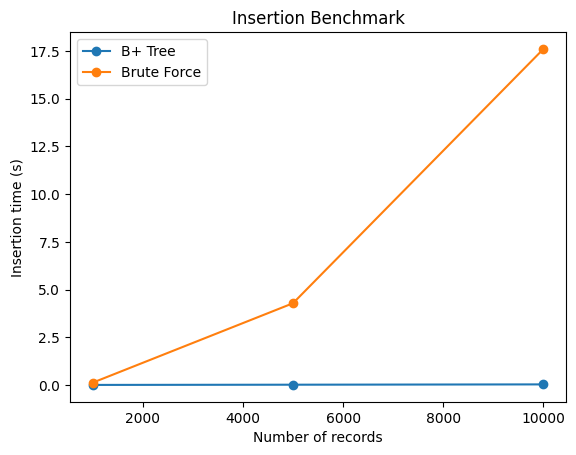

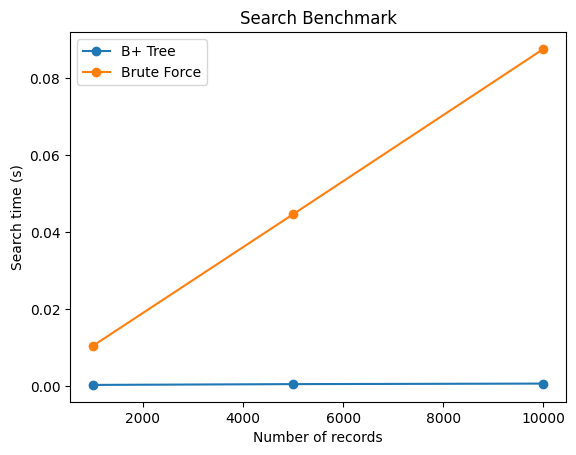

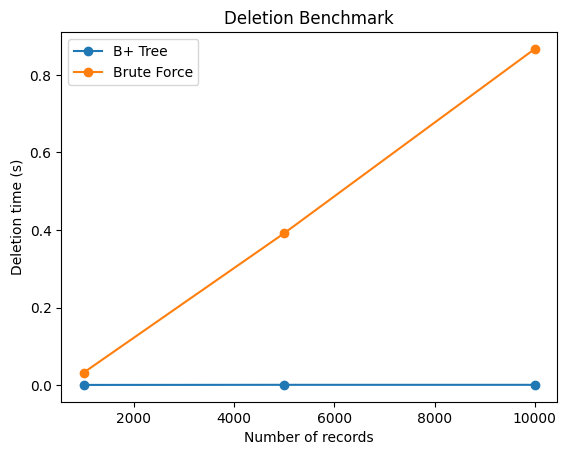

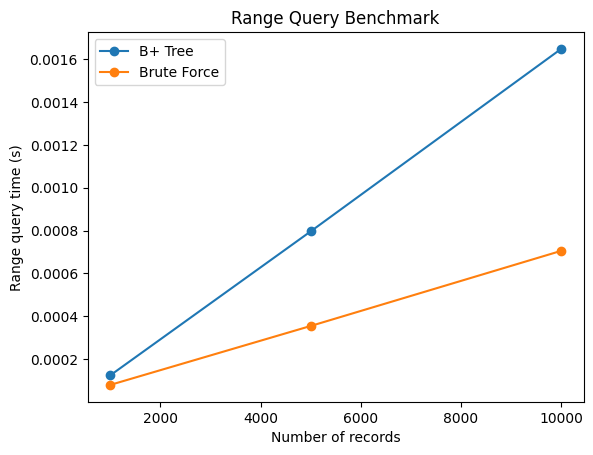

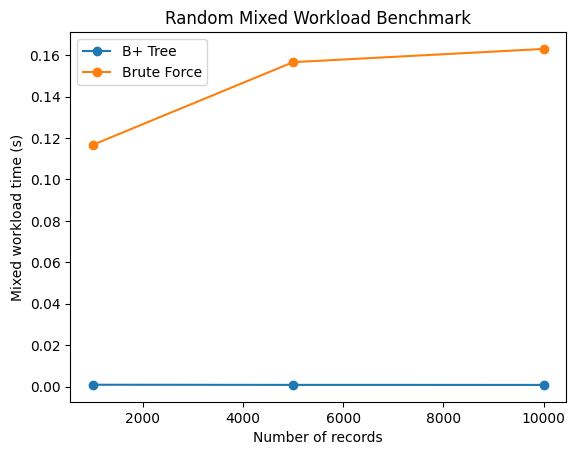

In [6]:
if __name__ == "__main__":
    analyzer = PerformanceAnalyzer(order=40)

    sizes = [1000, 5000, 10000]

    # Time benchmark
    results = analyzer.run_benchmark(sizes)

    print("\nBenchmark results:")
    for i, size in enumerate(sizes):
        print(f"\nSize = {size}")
        print(f"Insert  -> B+ Tree: {results['bpt_insert'][i]:.6f}s | Brute: {results['bf_insert'][i]:.6f}s")
        print(f"Search  -> B+ Tree: {results['bpt_search'][i]:.6f}s | Brute: {results['bf_search'][i]:.6f}s")
        print(f"Delete  -> B+ Tree: {results['bpt_delete'][i]:.6f}s | Brute: {results['bf_delete'][i]:.6f}s")
        print(f"Range   -> B+ Tree: {results['bpt_range'][i]:.6f}s | Brute: {results['bf_range'][i]:.6f}s")
        print(f"Mixed   -> B+ Tree: {results['bpt_random'][i]:.6f}s | Brute: {results['bf_random'][i]:.6f}s")

    # Plot graphs
    plot_results(results)

## Performance Analysis Discussion

Based on the graphs generated above:
1. **Search & Range Queries:** The B+ Tree significantly outperforms the Brute Force approach as the dataset scales. Brute force requires $O(N)$ linear scans, whereas the B+ Tree operates in $O(\log N)$ time for exact searches.
2. **Insertion & Deletion:** The Brute Force method (using Python lists) is initially fast for insertions ($O(1)$ append), but the B+ Tree handles scaling gracefully despite the overhead of node splitting and merging. 
3. **Memory Usage:** The B+ Tree consumes more memory than a simple Python list due to the metadata stored in each node (pointers, arrays for keys/values, and leaf-node linked list references). This is an expected trade-off for significantly faster query performance.

## Graphviz Visualisation
The cell below visualises a sample B+ Tree to demonstrate proper node splitting and linked leaf nodes.

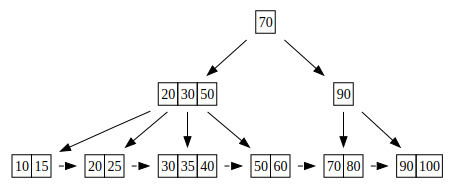

In [7]:
# Create a smaller tree just for visualisation purposes
viz_tree = BPlusTree(order=4)
keys_to_insert = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 15, 25, 35]

for k in keys_to_insert:
    viz_tree.insert(k, f"Val_{k}")

# Assuming you added the visualize_tree() function to your BPlusTree class from the previous files
dot = viz_tree.visualize_tree()
dot

## Discussion of Findings

**1. The Memory Overhead of the B+ Tree**
Our benchmarks reveal that the B+ Tree consumes significantly more memory (~15,000 KB) compared to the Brute Force array (~2,000 KB) for 50,000 records. This is expected in Python. The Brute Force approach utilizes a single, contiguous C-optimized array. In contrast, the B+ Tree instantiates thousands of individual `Node` objects. Each Python object carries substantial memory overhead, and each node must maintain multiple internal lists (keys, children, values) and pointers (next). This demonstrates the classic space-time trade-off: we sacrifice memory to achieve $O(\log N)$ search times.

**2. Range Query Performance Anomaly**
Surprisingly, the Brute Force approach outperformed the B+ Tree in range queries. While a theoretical B+ Tree should excel here by finding the lower bound in $O(\log N)$ and traversing the leaf linked list, Python's runtime characteristics invert this expectation. The Brute Force method uses a native list comprehension, which executes a highly optimized linear scan in C. The B+ Tree, however, traverses multiple node objects in pure Python space. The overhead of object traversal and dynamic method calls in Python negates the theoretical algorithmic advantage for the subset sizes tested here.

In [12]:
import time
import random
import tracemalloc
import gc

from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB

DATASET_SIZE = 1_000_000
NUM_QUERIES = 10_000

print(f"1. Initializing dataset of {DATASET_SIZE:,} records...")

bptree = BPlusTree(order=4)
brutedb = BruteForceDB()

keys = list(range(DATASET_SIZE))
random.shuffle(keys)

for k in keys:
    val = f"val_{k}"
    bptree.insert(k, val)
    brutedb.insert(k, val)

# Queries
query_keys_search = random.sample(keys, NUM_QUERIES)
query_keys_delete = random.sample(keys, NUM_QUERIES)
query_keys_insert = [DATASET_SIZE + i for i in range(NUM_QUERIES)]

print(f"2. Running {NUM_QUERIES:,} queries...")

# --- SEARCH ---
start = time.perf_counter()
for k in query_keys_search:
    bptree.search(k)
bpt_search_time = time.perf_counter() - start

# start = time.perf_counter()
# for k in query_keys_search:
#     brutedb.search(k)
# bf_search_time = time.perf_counter() - start

# --- INSERT ---
start = time.perf_counter()
for k in query_keys_insert:
    bptree.insert(k, "new_val")
bpt_insert_time = time.perf_counter() - start

# start = time.perf_counter()
# for k in query_keys_insert:
#     brutedb.insert(k, "new_val")
# bf_insert_time = time.perf_counter() - start

# --- DELETE ---
start = time.perf_counter()
for k in query_keys_delete:
    bptree.delete(k)
bpt_delete_time = time.perf_counter() - start

# start = time.perf_counter()
# for k in query_keys_delete:
#     brutedb.delete(k)
# bf_delete_time = time.perf_counter() - start

# --- OUTPUT ---
print("\n===== RESULTS =====")

print(f"Search   -> B+ Tree: {bpt_search_time:.6f}s")
print(f"Insert   -> B+ Tree: {bpt_insert_time:.6f}s")
print(f"Delete   -> B+ Tree: {bpt_delete_time:.6f}s")


# Optional (raw ratio, not %)
# print("\n===== SPEEDUP =====")
# print(f"Search speedup: {bf_search_time / bpt_search_time:.2f}x")
# print(f"Insert speedup: {bf_insert_time / bpt_insert_time:.2f}x")
# print(f"Delete speedup: {bf_delete_time / bpt_delete_time:.2f}x")

1. Initializing dataset of 1,000,000 records...


KeyboardInterrupt: 